In [3]:
# ================================================
# Notebook 3: Improved EasyOCR with Line Segmentation + Zoom
# ================================================

print("🔤 Notebook 3: EasyOCR with Line Segmentation & Zoom")

🔤 Notebook 3: EasyOCR with Line Segmentation & Zoom


In [4]:
# Install
%pip install easyocr pyspellchecker --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import easyocr
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import os
from spellchecker import SpellChecker

print(f"✅ Setup done | GPU: {torch.cuda.is_available()}")

✅ Setup done | GPU: True


In [2]:
# Cell 2: Strong Preprocessing Function
def preprocess_handwriting(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Strong contrast
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    
    # Sharpen
    sharpened = cv2.addWeighted(enhanced, 2.8, cv2.GaussianBlur(enhanced, (0,0), 3), -1.8, 0)
    
    # Binary
    thresh = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)
    
    kernel = np.ones((2,2), np.uint8)
    final = cv2.dilate(thresh, kernel, iterations=1)
    
    return final

In [3]:
# Cell 3: Initialize EasyOCR
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
print("✅ EasyOCR initialized")

✅ EasyOCR initialized


In [4]:
# Cell 4: Main Improved Recognition with Line Segmentation + Zoom
def recognize_text(image_path):
    original = cv2.imread(image_path)
    display_img = original.copy()
    
    # Show original
    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    plt.show()
    
    # Preprocess
    processed = preprocess_handwriting(image_path)
    
    # Find horizontal lines using contours
    contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])  # Sort top to bottom
    
    print("🤖 Processing lines with zoom...")
    recognized_lines = []
    
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        if h < 20 or w < 50:  # Filter noise
            continue
            
        # Crop the line
        crop = processed[y:y+h, x:x+w]
        
        # Zoom in (enlarge) the crop
        zoomed = cv2.resize(crop, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
        
        # Run OCR on zoomed line
        result = reader.readtext(zoomed, detail=1, paragraph=False)
        
        for detection in result:
            text = detection[1].strip()
            conf = detection[2]
            if len(text) > 2 and conf > 0.25:
                recognized_lines.append(text)
                print(f"Line {i+1}: {text} (Conf: {conf:.3f})")
    
    final_text = "\n".join(recognized_lines)
    
    print("\n" + "="*90)
    print("✅ FINAL RECOGNIZED TEXT:")
    print("="*90)
    print(final_text)
    print("="*90)
    
    return final_text


Processing: 1_3xUyINxRtDf2qowd-kkGQA.jpg


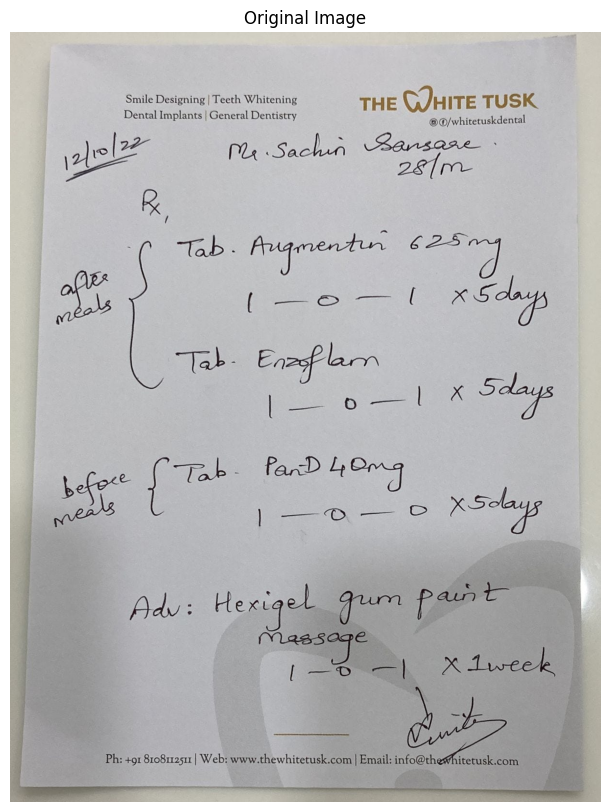

🤖 Processing lines with zoom...

✅ FINAL RECOGNIZED TEXT:


✅ Result saved to: recognized_text.txt

You can open the file to see the full output.


In [5]:
# Cell 5: Test - Local Version (VS Code / Jupyter)

import os
from pathlib import Path

# ====================== CONFIGURATION ======================
# Change this path to your actual image
image_path = r"C:\Users\Avilasha\Desktop\handwriting-ocr\input_images\1_3xUyINxRtDf2qowd-kkGQA.jpg"

# OR use this to automatically pick the first image in the folder:
# image_path = None

# ===========================================================

if image_path is None:
    # Auto pick first image from input_images folder
    input_folder = r"C:\Users\Avilasha\Desktop\handwriting-ocr\input_images"
    images = [f for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        image_path = os.path.join(input_folder, images[0])
        print(f"Auto selected: {images[0]}")
    else:
        print("❌ No images found in input_images folder!")
        raise FileNotFoundError("Please add an image to the folder")

# Run recognition
print(f"\nProcessing: {Path(image_path).name}")
text = recognize_text(image_path)

# Save result
output_file = "recognized_text.txt"
with open(output_file, "w", encoding="utf-8") as f:
    f.write(text)

print(f"\n✅ Result saved to: {output_file}")
print("\nYou can open the file to see the full output.")